# Gaia BH3

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from exogaia.data import GaiaAstrometry
from exogaia.leastsq import LeastSquares
from exogaia.samplers import MCMCSampler
from exogaia.results import SamplingResults

In [3]:
epoch_astrom = GaiaAstrometry(primary_mass=None, gaia_release="DR4")
epoch_astrom.retrieve_gaia_bh3(exclude_outliers=True, combine_ccds=False)


Gaia astrometry

Gaia release: DR4
Reference epoch: J2017.500

---------------
Querying source
---------------

Gaia release: DR3
Source ID: 4318465066420528000

INFO: Query finished. [astroquery.utils.tap.core]

RA = 294.828 deg +/- 0.051 mas
Dec = 14.931 deg +/- 0.052 mas
Parallax = 1.644 +/- 0.069 mas
Proper motion in RA = -22.235 +/- 0.062 mas/yr
Proper motion in Dec = -155.276 +/- 0.059 mas/yr
G-band magnitude = 11.231
Pseudocolor = 1.48 um-1

UWE = 6.18
RUWE = 3.41
Astrometric excess noise (mas) = 0.6550 +/- 0.0014
Non single star = 0

-------------------
Gaia BH3 epoch data
-------------------

Gaia release: DR4
Reference epoch: J2017.500
Source ID: 4318465066420528000

Primary mass (Msun): 0.76 +/- 0.05

Data file: /Users/tomasstolker/code/exogaia/data/gaiabh3_epochast.dat
Data shape: (599, 12)


In [4]:
print(epoch_astrom)

          transit_id  ccd_id  obs_time_tcb  centroid_pos_al  centroid_pos_error_al  parallax_factor_al  scan_pos_angle  outlier_flag  sin_scan_ang  cos_scan_ang  relative_time_year  relative_time_day
0  20114916805338633       1   2014.820290          147.066                  0.370             0.70828      -59.046727             0     -0.857587      0.514339           -2.679710        -978.764022
1  20114916805338633       2   2014.820290          146.696                  0.231             0.70828      -59.046771             0     -0.857587      0.514338           -2.679710        -978.763966
2  20114916805338633       3   2014.820290          146.685                  0.183             0.70828      -59.046816             0     -0.857588      0.514338           -2.679710        -978.763909
3  20114916805338633       4   2014.820291          146.557                  0.151             0.70828      -59.046867             0     -0.857588      0.514337           -2.679709        -978.763844


In [5]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)

In [6]:
aen = leastsq.calc_excess_noise()


------------------------
Astrometric excess noise
------------------------

Number of iterations = 4
Number of function evaluations = 12
Number of Jacobian evaluations: 6

Astrometric excess noise (mas) = 6.7798 +/- 0.0040



--------------------------
Single star (5 parameters)
--------------------------

Reduced chi^2 = 3090.339
RUWE = 30.709
F2 estimator = 701.387
Inflation factor = 55.622

Best-fit parameters:
   - RA offset = 1.506 +/- 0.053 mas
   - Dec offset = -0.033 +/- 0.050 mas
   - Parallax = 0.715 +/- 0.065 mas
   - mu in RA = -30.297 +/- 0.036 mas/yr
   - mu in Dec = -148.622 +/- 0.032 mas/yr


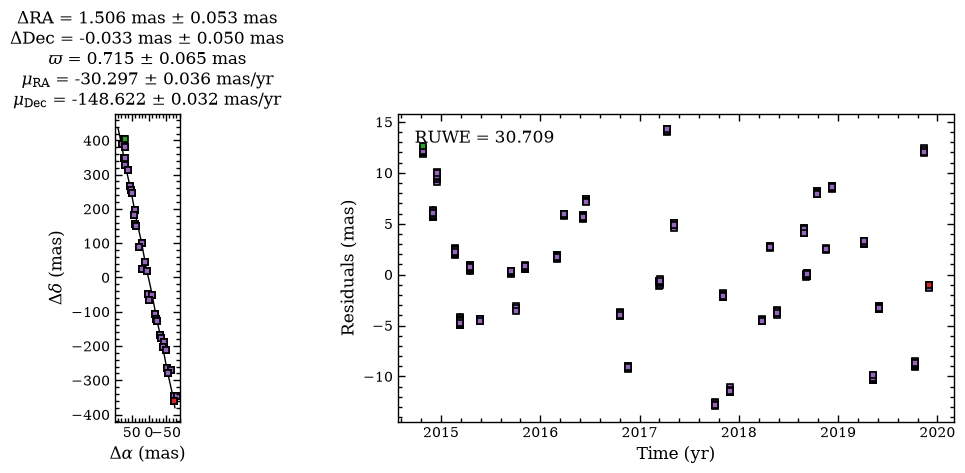

In [7]:
fig = leastsq.singl_5param(plot_file='plot.png')

In [8]:
print(leastsq)

LeastSquares(Δα = 1.50624 mas, Δδ = -0.0334119 mas, ϖ = 0.7152 mas, μ_α = -30.2968 mas/yr, μ_δ = -148.622 mas/yr)



--------------------------
Orbit grid (12-parameters)
--------------------------



  0%|          | 0/900 [00:00<?, ?it/s]


Best-fit RUWE = 0.820

Best-fit stellar track:
   - RA offset (mas) = 2.913 +/- 0.024
   - Dec offset (mas) = 4.096 +/- 0.019
   - Parallax (mas) = 1.671 +/- 0.011
   - mu in RA (mas/yr) = -26.910 +/- 0.025
   - mu in Dec (mas/yr) = -157.775 +/- 0.021

Best-fit orbit:
   - Period (days) = 7273.003
   - Eccentricity = 0.800
   - Relative time of periastron = 0.03
   - Thiele-Innes A = 3.413 +/- 0.040
   - Thiele-Innes B = 15.582 +/- 0.047
   - Thiele-Innes F = 31.929 +/- 0.054
   - Thiele-Innes G = -24.876 +/- 0.060

Derived parameters:
   - Semi-major axis of photocenter (mas) = 41.137 +/- 0.052
   - Relative semi-major axis (au) = 25.092
   - Mass function (Msun) = 3.761e+01
   - Companion mass (Msun) = 3.908e+01

Conversion to campbell elements:
   - Period = 7273.003 days
   - Eccentricity = 0.800
   - Relative time of periastron = 0.033
   - Semi-major axis of photocenter (mas) = 41.137
   - Inclination (deg) = 110.130
   - Argument of periastron (deg) = 79.033
   - PA of ascendin

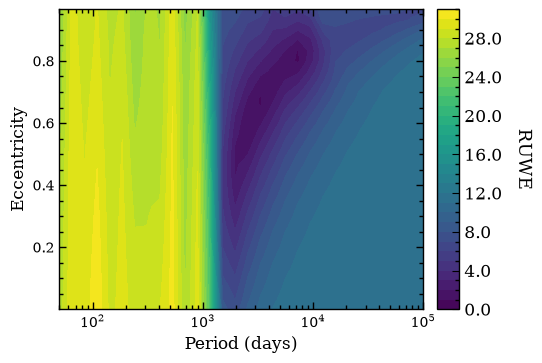

In [9]:
fig = leastsq.orbit_grid(map_type='ruwe', plot_file='plot.png', n_points=30)

In [10]:
print(leastsq)

LeastSquares(Δα = 2.91282 mas, Δδ = 4.0957 mas, ϖ = 1.67135 mas, μ_α = -26.9102 mas/yr, μ_δ = -157.775 mas/yr, P = 7273 days, e = 0.799999, τ = 0.0333343, a = 41.1375 mas, i = 1.92214 rad, ω = 1.37939 rad, Ω = 2.41314 rad)



-------------------------
Orbit fit (12 parameters)
-------------------------

Reduced chi^2: 0.452
RUWE: 0.371

Best-fit stellar track:
   - RA offset (mas) = 4.264 +/- 0.060
   - Dec offset (mas) = 2.423 +/- 0.086
   - Parallax (mas) = 1.682 +/- 0.009
   - mu in RA (mas/yr) = -28.329 +/- 0.077
   - mu in Dec (mas/yr) = -155.197 +/- 0.129

Best-fit orbit:
   - Period (days) = 4233.299 +/- 113.208
   - Eccentricity = 0.728 +/- 0.006
   - Relative time of periastron = 0.057 +/- 0.002
   - Semi-major axis of photocenter (mas) = 27.290 +/- 0.567
   - Inclination (deg) = 110.584 +/- 0.106
   - Argument of periastron (deg) = 77.851 +/- 0.168
   - PA of ascending node (deg) = 136.211 +/- 0.146
   - Jitter (mas) = 0.031 +/- 0.005

Number of function evaluations: 32
Number of Jacobian evaluations: 31

Derived parameters:
   - Relative semi-major axis (au) = 16.597
   - Mass function (Msun) = 3.181e+01
   - Companion mass (Msun) = 3.328e+01


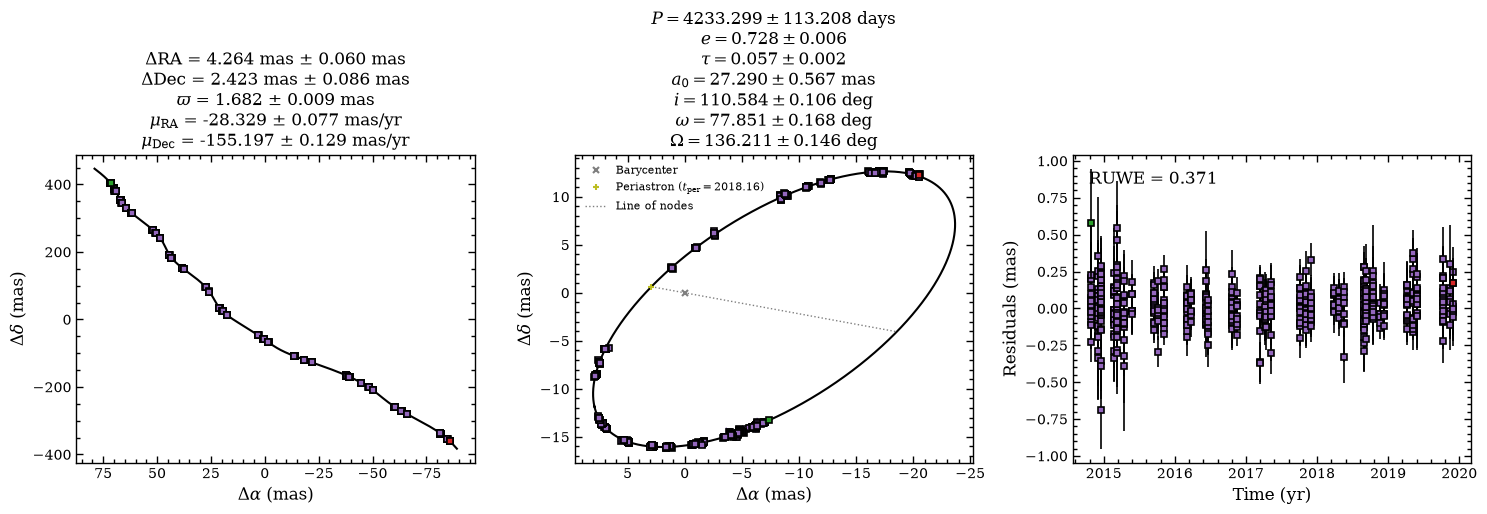

In [11]:
fig = leastsq.orbit_fit(inc_jitter=True, plot_file='plot.png')

In [12]:
print(leastsq)

LeastSquares(Δα = 4.26444 mas, Δδ = 2.42267 mas, ϖ = 1.68182 mas, μ_α = -28.3293 mas/yr, μ_δ = -155.197 mas/yr, P = 4233.3 days, e = 0.728164, τ = 0.0568263, a = 27.2902 mas, i = 1.93006 rad, ω = 1.35875 rad, Ω = 2.37732 rad)


In [13]:
sampler = MCMCSampler(epoch_astrometry=epoch_astrom, least_squares=leastsq)


MCMC sampler

Primary mass (Msun) = 0.76 +/- 0.05
Number of parameters: 12

Priors:
   - ra_offset -> Normal: [4.26, 0.10]
   - dec_offset -> Normal: [2.42, 0.10]
   - parallax -> Normal: [1.68, 0.10]
   - pmra -> Normal: [-28.33, 0.10]
   - pmdec -> Normal: [-155.20, 0.10]
   - per -> Normal: [4233.30, 113.21]
   - ecc -> Normal: [0.73, 0.01]
   - tau -> Normal: [0.06, 0.00]
   - sma -> Normal: [27.29, 0.57]
   - inc -> Normal: [1.93, 0.00]
   - aop -> Normal: [1.36, 0.00]
   - pan -> Normal: [2.38, 0.00]


In [14]:
sampler.run_ptmcmc(
    pickle_file="exogaia.pkl",
    n_temps=10,
    n_walkers=200,
    n_steps=1000,
    n_sweeps=1,
    progress=True,
)


-------------
Run reddemcee
-------------



100%|███████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [09:02<00:00, 18.45it/s]
The chain is shorter than 50 times the integrated autocorrelation time for 12 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [56.1600706  57.08782068 57.11035745 55.11715608 56.82737145 54.75477183
 56.31525594 54.96885728 54.76242744 55.69543807 57.70674859 60.76819104]
The chain is shorter than 50 times the integrated autocorrelation time for 12 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [57.47683088 57.20779076 57.03043484 52.86403002 54.79692849 53.47599223
 53.83547972 55.37023682 52.6548263  59.26242466 62.11716283 60.51672791]
The chain is shorter than 50 times the integrated autocorrelation time for 12 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [63.34337203 59.08806249 59.69213476 62.56805301 61.65133182 61.27122478
 60.08866

In [15]:
results = SamplingResults(burnin=500, pickle_file="exogaia.pkl")


Fit results

Number of parameters: 12
Samples shape: (10, 1000, 200, 12)

Burnin: 500
Samples shape: (10, 500, 200, 12)

Reshaped samples: (1000000, 12)



------------
Plot walkers
------------

Number of walkers: 100
Thin value: 1
Output file: plot.png


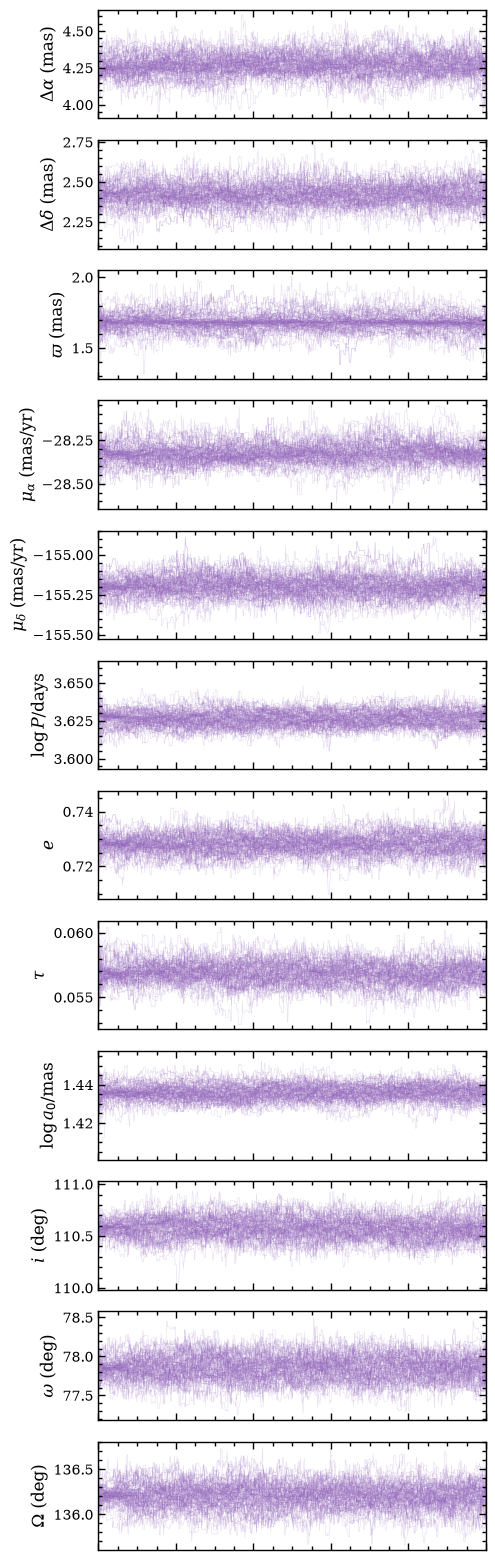

In [16]:
fig = results.plot_walkers(n_walkers=100, thin=None, plot_file="plot.png")


--------------
Plot posterior
--------------

Output file: plot.png


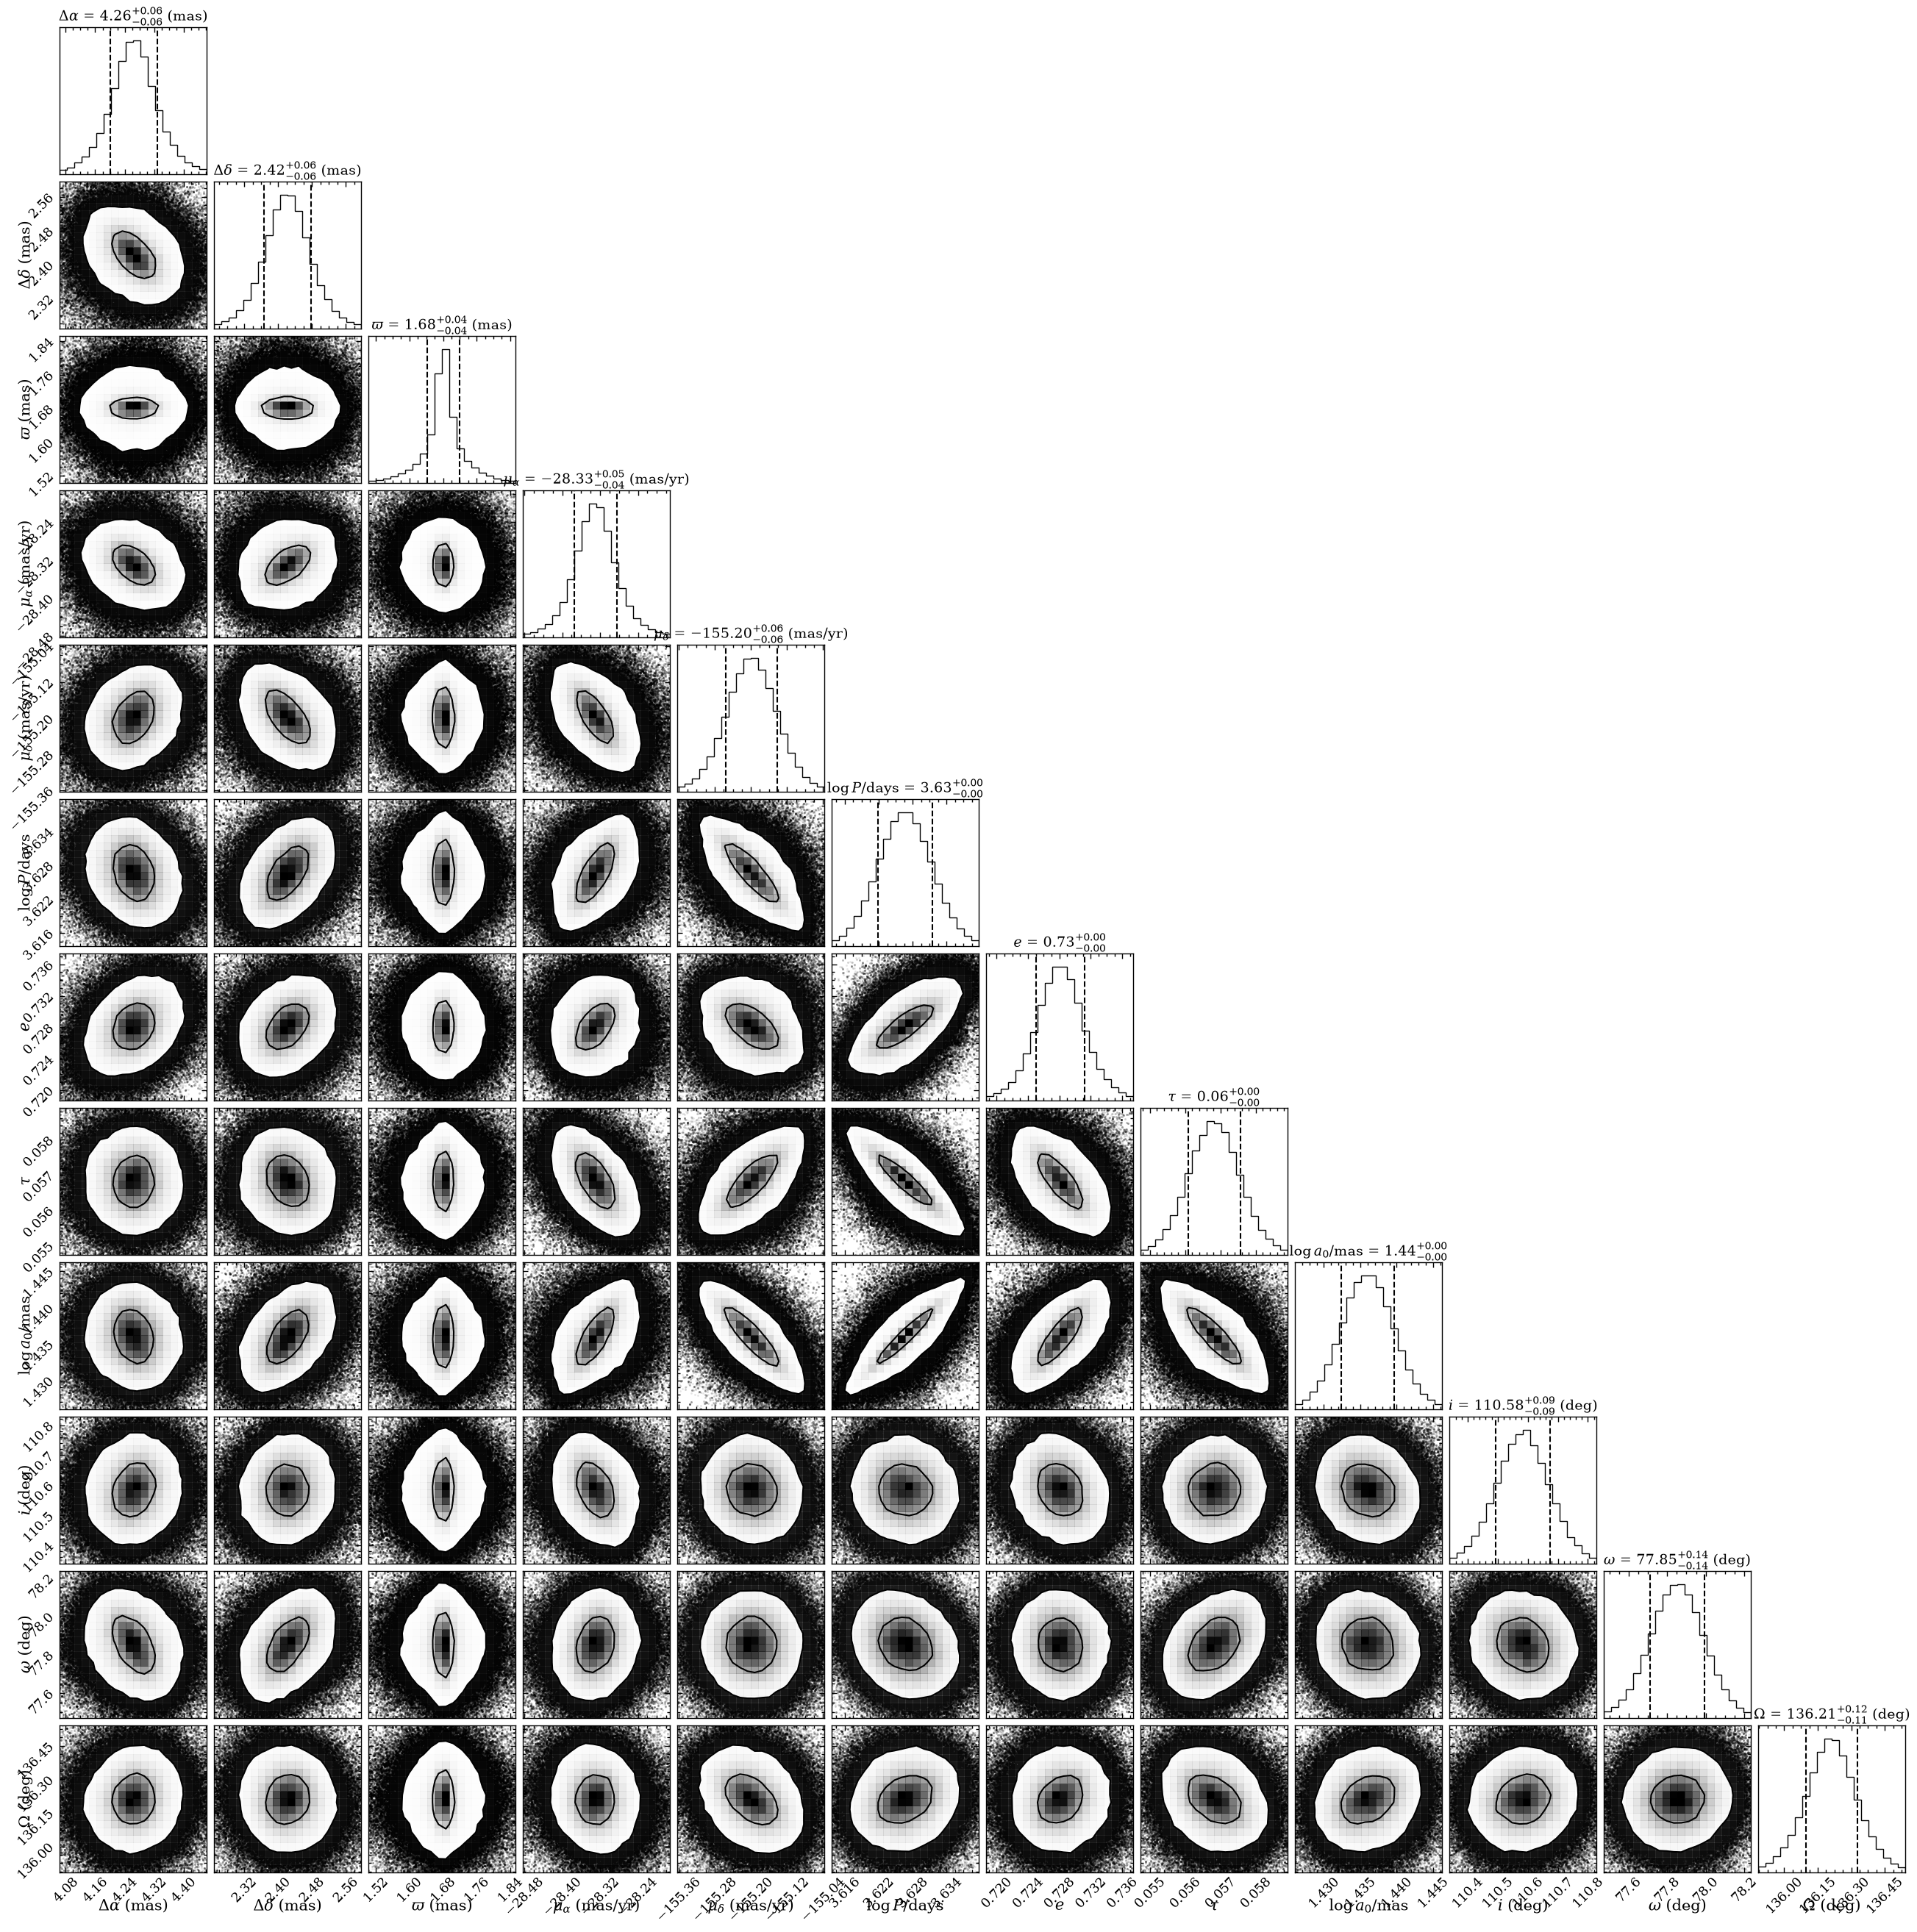

In [17]:
fig = results.plot_posterior(truths=None, plot_file="plot.png")


--------------
Plot residuals
--------------


Kepler model

Epoch astrometry: GaiaAstrometry

-----------------------
Calculate stellar track
-----------------------

Stellar parameters:
   - RA offset (mas) = 4.261
   - Dec offset (mas) = 2.433
   - Parallax (mas) = 1.681
   - Proper motion in RA (mas/yr) = -28.325
   - Proper motion in Dec (mas/yr) = -155.214

---------------------
Calculate orbit model
---------------------

Orbit parameters:
   - Period (days) = 4247.453
   - Eccentricity = 0.729
   - Relative time of periastron = 0.057
   - Semi-major axis (mas) = 27.365
   - Inclination (deg) = 110.582
   - Argument of periastron (deg) = 77.857
   - PA of ascending node (deg) = 136.224


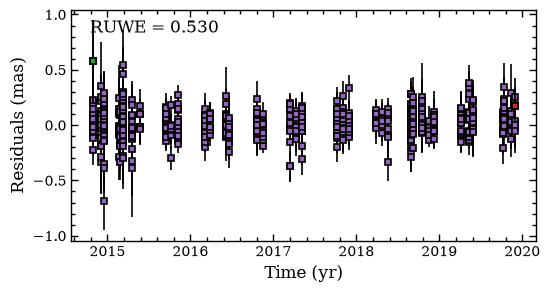

In [18]:
fig = results.plot_residuals(plot_file="plot.png")


----------
Plot orbit
----------



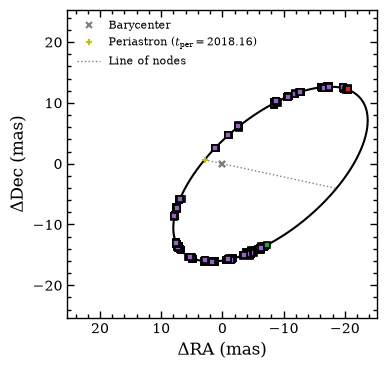

In [19]:
fig = results.plot_orbit(plot_file="plot.png")